# 5장 - 성향점수
 


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import graphviz as gr
from matplotlib import style
import seaborn as sns
from matplotlib import pyplot as plt
style.use("ggplot")
import statsmodels.formula.api as smf
import matplotlib
from cycler import cycler

color=['0.2', '0.6', '1.0']
default_cycler = (cycler(color=color))
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']


plt.rc('axes', prop_cycle=default_cycler)

## 5.1 관리자 교육의 효과
* 불응 (non-compliance) 은 실험 대상이 의도한 처치를 받지 못하는 상태를 말한다. 이는 교란 요인을 보정해야하는 상황에서 실험군과 대조군을 비교가능한 상태로 만들지 못하게 하는 상태 중 하나이다.
* 예시
    * 한 기업에서 새로운 관리자들을 대상으로 한 교육 프로그램의 효과를 측정하기 위해 무작위로 프로그램에 참여시키고자 함
    * 아래와 같이 실험군과 대조군 간의 공변량을 포함한 데이터가 주어진 상황

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/management_training.csv")
df.head()

,departament_id,intervention,engagement_score,tenure,n_of_reports,gender,role,last_engagement_score,department_score,department_size
0,76,1,0.277359,6,4,2,4,0.614261,0.224077,843
1,76,1,-0.449646,4,8,2,4,0.069636,0.224077,843
2,76,1,0.769703,6,4,2,4,0.866918,0.224077,843
3,76,1,-0.121763,6,4,2,4,0.029071,0.224077,843
4,76,1,1.526147,6,4,1,4,0.589857,0.224077,843


## 5.2 회귀분석과 보정
* 회귀분석을 통해 교란 요인을 보정하는 과정은 아래와 같다.
* 효과 추정값이 처음의 추정값보다 훨씬 작아진 것을 볼 수 있고, 이는 긍정 편향 (positive bias) 이 있었다는 것을 알 수 있다.

In [3]:
import statsmodels.formula.api as smf

smf.ols("engagement_score ~ intervention",
        data=df).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-0.2347,0.014,-16.619,0.000,-0.262,-0.207
intervention,0.4346,0.019,22.616,0.000,0.397,0.472


In [4]:
model = smf.ols("""engagement_score ~ intervention 
+ tenure + last_engagement_score + department_score
+ n_of_reports + C(gender) + C(role)""", data=df).fit()

print("ATE:", model.params["intervention"])
print("95% CI:", model.conf_int().loc["intervention", :].values.T)

ATE: 0.2677908576676859
95% CI: [0.23357751 0.30200421]


## 5.3 성향점수
* 성향 점수 가중치는 성향점수라는 개념을 중심으로 이루어지며, 이는 교란 요인 X를 직접 통제할 필요 없이 균형점수를 통제해 조건부 독립성을 만족할 수 있게 하는 방법이다.
* 이 균형점수는 종종 처치의 조건부 확률이나 성향점수라고 부른다.
* 성향점수는 일종의 차원 축소 기법으로 볼 수도 있다. 고차원일 수 있는 X를 조건부로 설정하는 대신, 성향점수를 조건부로 두고 X로 유입되는 backdoor path 를 차단할 수 있다.

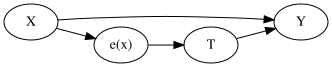

In [5]:
g = gr.Digraph(graph_attr={"rankdir":"LR"})
g.edge("T", "Y")
g.edge("X", "Y")
g.edge("X", "e(x)")
g.edge("e(x)", "T")

g

### 5.3.1 성향점수 추정
* 현실에서 처치 배정 메커니즘을 대부분 알 수 없으며, 실제 성향점수를 추정값으로 대체해야 한다.
* 위 교육프로그램 예시에서는 처치가 이진 변수이므로 $e(x)$ 를 추정할 때 로지스틱 회귀를 사용하는 것이 좋다.

In [6]:
ps_model = smf.logit("""intervention ~ 
tenure + last_engagement_score + department_score
+ C(n_of_reports) + C(gender) + C(role)""", data=df).fit(disp=0)

In [7]:
data_ps = df.assign(
    propensity_score = ps_model.predict(df),
)

data_ps[["intervention", "engagement_score", "propensity_score"]].head()

,intervention,engagement_score,propensity_score
0,1,0.277359,0.596106
1,1,-0.449646,0.391138
2,1,0.769703,0.602578
3,1,-0.121763,0.580990
4,1,1.526147,0.619976


### 5.3.2 성향점수와 직교화
* OLS 는 성향점수 추정과 매우 비슷하게 처치 배정 매커니즘을 모델링한다. 아래와 같이 성향점수를 선형회귀에 포함시켜 얻은 ATE 추정값은 처치 및 교란 요인 X를 사용해 선형회귀분석을 적합시킨 결과와 매우 유사하다.

In [8]:
model = smf.ols("engagement_score ~ intervention + propensity_score",
                data=data_ps).fit()
model.params["intervention"]

0.26331267490277116

### 5.3.3 성향점수 매칭
* 성향점수를 통제하는 또 다른 접근 방식은 Matching estimator 이다.
* 이는 관측 가능한 특징이 비슷한 실험 대상의 짝을 찾아 실험군과 대조군을 비교하는 방법이다. 
* 다양한 방법을 활용할 수 있으나 아래 예시에서는 KNN 을 통해 최근접 이웃이 1인 알고리즘을 활용한다.
    * 성향점수를 유일한 특성으로 사용해 실험군에 KNN 모델을 적합시키고 대조군의 $Y_1$을 대체하는데 사용한다.
    * 대조군에 KNN모델을 적합해 실험군의 $Y_0$를 대체한다.
    * 실험 대상의 matching이 끝나면 ATE 추정식을 통해 계산해 추정량을 구할 수 있다.
* 반드시 성향점수를 기준으로 matching을 진행할 필요는 없으나, X에 대해 바로 matching을 수행할 경우 차원이 클수록 편향이 커질 가능성이 높아진다. 

In [9]:
from sklearn.neighbors import KNeighborsRegressor

T = "intervention"
X = "propensity_score"
Y = "engagement_score"

treated = data_ps.query(f"{T}==1")
untreated = data_ps.query(f"{T}==0")

mt0 = KNeighborsRegressor(n_neighbors=1).fit(untreated[[X]],
                                             untreated[Y])

mt1 = KNeighborsRegressor(n_neighbors=1).fit(treated[[X]], treated[Y])

predicted = pd.concat([
    # find matches for the treated looking at the untreated knn model
    treated.assign(match=mt0.predict(treated[[X]])),
    
    # find matches for the untreated looking at the treated knn model
    untreated.assign(match=mt1.predict(untreated[[X]]))
])

predicted.head()

,departament_id,intervention,engagement_score,tenure,n_of_reports,gender,role,last_engagement_score,department_score,department_size,propensity_score,match
0,76,1,0.277359,6,4,2,4,0.614261,0.224077,843,0.596106,0.557680
1,76,1,-0.449646,4,8,2,4,0.069636,0.224077,843,0.391138,-0.952622
2,76,1,0.769703,6,4,2,4,0.866918,0.224077,843,0.602578,-0.618381
3,76,1,-0.121763,6,4,2,4,0.029071,0.224077,843,0.580990,-1.404962
4,76,1,1.526147,6,4,1,4,0.589857,0.224077,843,0.619976,0.000354


In [10]:
np.mean((predicted[Y] - predicted["match"])*predicted[T] 
        + (predicted["match"] - predicted[Y])*(1-predicted[T]))

0.28777443474045966

### 5.3.4 역확률 가중치
* 성향점수를 활용하는 역확률 가중치(inverse propensity weighting)도 널리 사용된다. 
* 처치의 역확률에 따라 데이터의 가중치를 재조정해 데이터에서 처치가 무작위로 배정된 것처럼 보이게 할 수 있다.
    * 표본에 $1/P(T=t|X)$ 가중치를 부여
* 이는 마치 실험군에 속한 대상이 처치를 받을 확률이 낮다면 해당 샘플을 대조군과 매우 비슷한 것으로 여기는 방법이다.

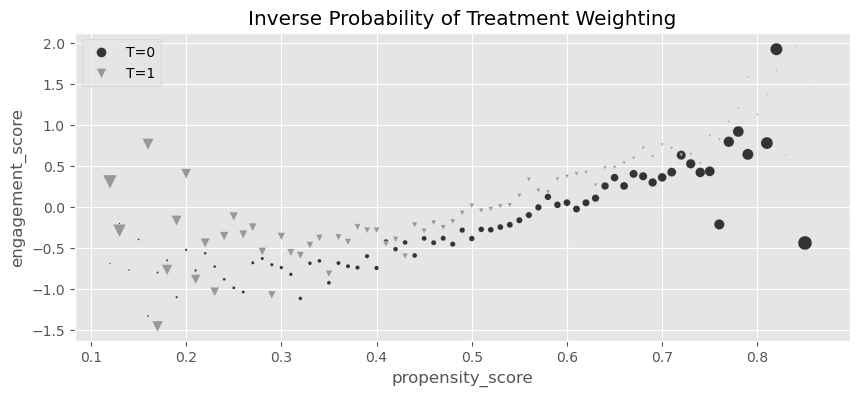

In [11]:
g_data = (data_ps
          .assign(
              weight = data_ps["intervention"]/data_ps["propensity_score"] + (1-data_ps["intervention"])/(1-data_ps["propensity_score"]),
              propensity_score=data_ps["propensity_score"].round(2)
          )
          .groupby(["propensity_score", "intervention"])
          [["weight", "engagement_score"]]
          .mean()
          .reset_index())

plt.figure(figsize=(10,4))
for t in [0, 1]:
    sns.scatterplot(data=g_data.query(f"intervention=={t}"), y="engagement_score", x="propensity_score", size="weight",
                    sizes=(1,100), color=color[t], legend=None, label=f"T={t}", marker=marker[t])

plt.title("Inverse Probability of Treatment Weighting")
plt.legend()


* 위 그래프에서 성향점수가 낮을 때 교육을 받은 관리자 (T=1)의 높은 가중치를 주목해서 보면 이는 교육받지 않은 것처럼 보이는 교육받은 관리자에게 높은 중요도를 부여하는 것과 같다.

In [12]:
weight_t = 1/data_ps.query("intervention==1")["propensity_score"]
weight_nt = 1/(1-data_ps.query("intervention==0")["propensity_score"])
t1 = data_ps.query("intervention==1")["engagement_score"] 
t0 = data_ps.query("intervention==0")["engagement_score"] 

y1 = sum(t1*weight_t)/len(data_ps)
y0 = sum(t0*weight_nt)/len(data_ps)

print("E[Y1]:", y1)
print("E[Y0]:", y0)
print("ATE", y1 - y0)

E[Y1]: 0.1165631723294674
E[Y0]: -0.14941553647814396
ATE 0.2659787088076114


In [13]:
# 위 식과 동일하게 단순화
np.mean(data_ps["engagement_score"] 
        * (data_ps["intervention"] - data_ps["propensity_score"]) 
        / (data_ps["propensity_score"]*(1-data_ps["propensity_score"])))

0.26597870880761154

### 5.3.5 역확률 가중치의 분산
* IPW(Inverse probability weighting) 추정값의 신뢰구간을 얻는 가장 간단한 방법은 부트스트랩 방법이다.
    * 데이터를 반복적으로 복원추출해 여러 IPW 추정값의 2.5번째와 97.5번쨰 백분위수를 계산해 95%신뢰구간을 구함
* 코드 구현
    * IPW 추정 과정을 함수로 구현
    * 반복문을 통해 실행되는 부트스트랩 표본마다 추정값이 반환되어 추정값의 array 가 생성됨
    * 생성된 array 에서 백분위수를 구해 신뢰구간 반환

In [14]:
from sklearn.linear_model import LogisticRegression
from patsy import dmatrix

# define function that computes the IPW estimator
def est_ate_with_ps(df, ps_formula, T, Y):
    
    X = dmatrix(ps_formula, df)
    ps_model = LogisticRegression(max_iter=1000).fit(X, df[T])
    ps = ps_model.predict_proba(X)[:, 1]
    
    # compute the ATE
    return np.mean((df[T]-ps) / (ps*(1-ps)) * df[Y]) 

In [15]:
formula = """tenure + last_engagement_score + department_score
+ C(n_of_reports) + C(gender) + C(role)"""
T = "intervention"
Y = "engagement_score"

est_ate_with_ps(df, formula, T, Y)

0.26603194263569113

In [16]:
from joblib import Parallel, delayed # for parallel processing

def bootstrap(data, est_fn, rounds=200, seed=123, pcts=[2.5, 97.5]):
    np.random.seed(seed)
    
    stats = Parallel(n_jobs=4)(
        delayed(est_fn)(data.sample(frac=1, replace=True))
        for _ in range(rounds)
    )
    
    return np.percentile(stats, pcts)

In [17]:
from toolz import partial

print(f"ATE: {est_ate_with_ps(df, formula, T, Y)}")

est_fn = partial(est_ate_with_ps, ps_formula=formula, T=T, Y=Y)
print(f"95% C.I.: ", bootstrap(df, est_fn))


ATE: 0.26603194263569113
95% C.I.:  [0.22649263 0.30079711]


* partial 함수
    * partial은 주어진 함수와 해당 함수의 일부 인수들을 받아서, 이 인수들이 미리 적용된 새로운 함수를 만들어준다. 

In [18]:
def addNumber(x, number): return x + number
add2 = partial(addNumber, number=2)
add4 = partial(addNumber, number=4)
print(add2(3))
print(add4(3))
print(add2(5))

5
7
7


* 위 95% 신뢰구간은 앞서 선형회귀분석을 사용해 얻은 값과 비슷하다.
* 큰 가중치가 적용되면 성향점수 추정량의 분산이 크게 증가하므로 대조군의 실험대상이 적거나 성향점수가 낮은 부분에 실험군의 대상이 적은 경우 결과에 잡음이 많을 수 있다.

### 5.3.6 안정된 성향점수 가중치
* 가중치의 합이 원래 표본 크기와 거의 같은데 이는 가중치를 부여하면 실험군은 모든 대상이 처치 받은 것처럼, 대조군은 모든 대상이 처치 받지 않은 것처럼 행동하는 유사 모집단을 만든것이라 간주할 수 있다.
* 머신러닝 관점에서 IPW는 중요도 샘플링의 응용으로 볼 수 있다.
    * 원본 분포 $q(x)$ 의 데이터가 있는 가운데 목표 분포 $p(x)$ 에서 샘플링하고 싶을 때 q(x)의 데이터를 $p(x)/q(x)$ 로 재조정하는 방식
    * 실험군에 $1/P(T=1|X)$ 의 가중치를 주는 것은 $P(T=1)$ 분포에서 나온 데이터를 사용해 $P(T=1) =1$ 로 재구성하는 것을 의미한다.

In [19]:
print("Original Sample Size", data_ps.shape[0])
print("Treated Pseudo-Population Sample Size", sum(weight_t))
print("Untreated Pseudo-Population Sample Size", sum(weight_nt))

Original Sample Size 10391
Treated Pseudo-Population Sample Size 10435.08907919792
Untreated Pseudo-Population Sample Size 10354.298899788306


* 이 방법은 가중치가 너무 크지 않다면 괜찮지만 처치 확률이 매우 낮다면 계산상의 문제가 발생할 수 있다.
* 이를 위해 주변확률인 $P(T=t)$ 를 사용해 가중치를 안정화할 수 있다.
    * $$ w= \frac{P(T=t)}{P(T=t|X)} $$
* 안정된 가중치는 실험군과 대조군의 유효 크기가 각각 원래 실험군 대조군의 유효 크기와 일치하는 유사 모집단을 재구성한다.

In [20]:
p_of_t = data_ps["intervention"].mean()

t1 = data_ps.query("intervention==1")
t0 = data_ps.query("intervention==0")

weight_t_stable = p_of_t/t1["propensity_score"]
weight_nt_stable = (1-p_of_t)/(1-t0["propensity_score"])

print("Treat size:", len(t1))
print("W treat", sum(weight_t_stable))

print("Control size:", len(t0))
print("W treat", sum(weight_nt_stable))

Treat size: 5611
W treat 5634.80750874598
Control size: 4780
W treat 4763.116999421416


In [21]:
nt = len(t1)
nc = len(t0)

y1 = sum(t1["engagement_score"]*weight_t_stable)/nt
y0 = sum(t0["engagement_score"]*weight_nt_stable)/nc

print("ATE: ", y1 - y0)

ATE:  0.26597870880761143


### 5.3.7 유사 모집단
* $P(T|X)$ 의 관점에서 편향이 무엇을 의미하는지?
    * 처치가 10% 확률로 무작위 배정되었다면, 처치는 X에 독립적이며 $P(T|X) = P(T) = 10%$ 이다.
    * 처치와 X가 독립이라면 교란편향이 없고 보정할 필요가 없어진다. 
* 아래의 두 그래프를 비교해볼때, 왼쪽 그래프가 오른쪽 그래프로 변환된다고 가정해보면, x축 값이 낮은 영역에서의 실험군은 가중치가 증가하고 대조군은 감소한다. 반대로 x값이 높은 영역에서 실험군의 가중치가 낮아지고 대조군의 가중치가 높아진다. 이 보정으로 인해 두 분포가 겹치게된다. 이는 적용된 데이터에서 실험군과 대조군이 처치 받거나 받지 않을 확률이 같다는 것을 의미한다.

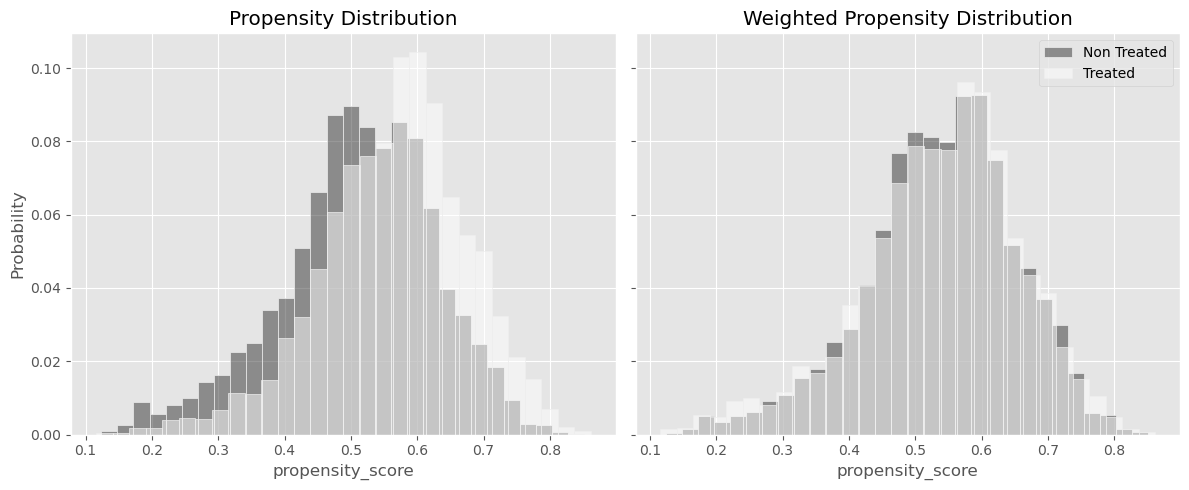

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)

sns.histplot(data_ps.query("intervention==0")["propensity_score"], stat="probability",
             label="Not Treated", color="C0", bins=30, ax=ax1, alpha=0.5)
sns.histplot(data_ps.query("intervention==1")["propensity_score"], stat="probability",
             label="Treated", color="C2", alpha=0.5, bins=30, ax=ax1)
ax1.set_title("Propensity Distribution")

sns.histplot(data_ps.query("intervention==0").assign(w=weight_nt_stable),
             x="propensity_score", stat="probability",
             color="C0", weights="w", label="Non Treated", bins=30, ax=ax2,  alpha=0.5)

sns.histplot(data_ps.query("intervention==1").assign(w=weight_t_stable),
             x="propensity_score", stat="probability",
             color="C2", weights="w", label="Treated", bins=30, alpha=0.5, ax=ax2)
ax2.set_title("Weighted Propensity Distribution")
plt.legend()

plt.tight_layout()


### 5.3.8 선택편향
* IPW 는 선택 문제를 보정하는데도 사용할 수 있다. 
* 예를 들어 앱에 대한 고객 만족도를 평가하는 설문을 보낸 예시를 생각해보자.
    * 일부 고객은 응답하지 않기 때문에 분석 결과가 편향될 수 있는 문제가 있다. (만약 미응답자 대부분이 앱에 불만족한다면 양의 편향이 있을 가능성)
    * 이를 보정하기 위해 고객의 공변량이 주어지면 응답률 $R, P(R=1|X)$ 를 추정할 수 있다. 그 다음 응답자에게 $1/\hat{P}(R=1)$ 만큼의 가중치를 부여한다. 이는 추정 응답률이 낮은 미응답자와 유사한 응답자에게 높은 가중치를 부여할 수 있다. 
    * 이는 설문 응답자는 자신뿐만아니라 자신과 비슷한 고객을 대표해 원래 모집단처럼 행동하지만 마치 모두가 설문에 응답한 것처럼 보이는 유사 모집단을 생성하는 방법이다.

### 5.3.9 편향-분산 트레이드오프
* T를 잘 예측하는 공변량 X가 있다면 이 변수는 $e(x)$ d에 대한 정확한 모델을 제공할 것이다. 하지만 해당 변수가 Y의 원인이 아니라면 이는 교란 요인이 아니며 IPW 추정값의 분산만 높이게 된다.
* IPW 에는 편향-분산 trade-off 가 존재한다. 일반적으로 성향 점수 모델이 정확할수록 편향은 작아지지만 매우 정확한 모델은 매우 부정확한 효과 추정값을 생성할 수도 있다.

### 5.3.10 성향점수의 양수성 가정
* 더 많은 변수를 추가해 $e(x)$에 대한 모델을 더 정교하게 만들수록 조건부 독립성 가정을 만족하는 방향으로 나아갈 수 있지만 동시에 양수성 가정의 타장성이 떨어지게 된다.
    * 대조군에서 멀리 떨어진 낮은 $\hat{e}(x)$ 영역에 처치가 집중되고 그 반대도 마찬가지이기 때문이다.
* 성향점수가 낮은(대조군이 될 확률이 높은) 영역에 처치 받은 표본이 아예 없다면 해당 영역에서 $Y_1$ 을 재구성하는 재조정은 불가능하므로 양수성 가정을 위배한다 볼 수 있다. 
* 아래의 예제 코드와 같이 $e(x)$가 거의 0에 가까운 곳에서 대조군 분포의 상당 부분이 모여있지만 해당 영역을 재구성할 실험군이 없어서 좋은 추정값을 얻지 못하게 된다.

In [23]:
np.random.seed(1)

n = 1000
x = np.random.normal(0, 1, n)
t = np.random.normal(x, 0.5, n) > 0

y0 = -x
y1 = y0 + t  # ate of 1

y = np.random.normal((1-t)*y0 + t*y1, 0.2)

df_no_pos = pd.DataFrame(dict(x=x,t=t.astype(int),y=y))

df_no_pos.head()

,x,t,y
0,1.624345,1,-0.526442
1,-0.611756,0,0.659516
2,-0.528172,0,0.438549
3,-1.072969,0,0.950810
4,0.865408,1,-0.271397


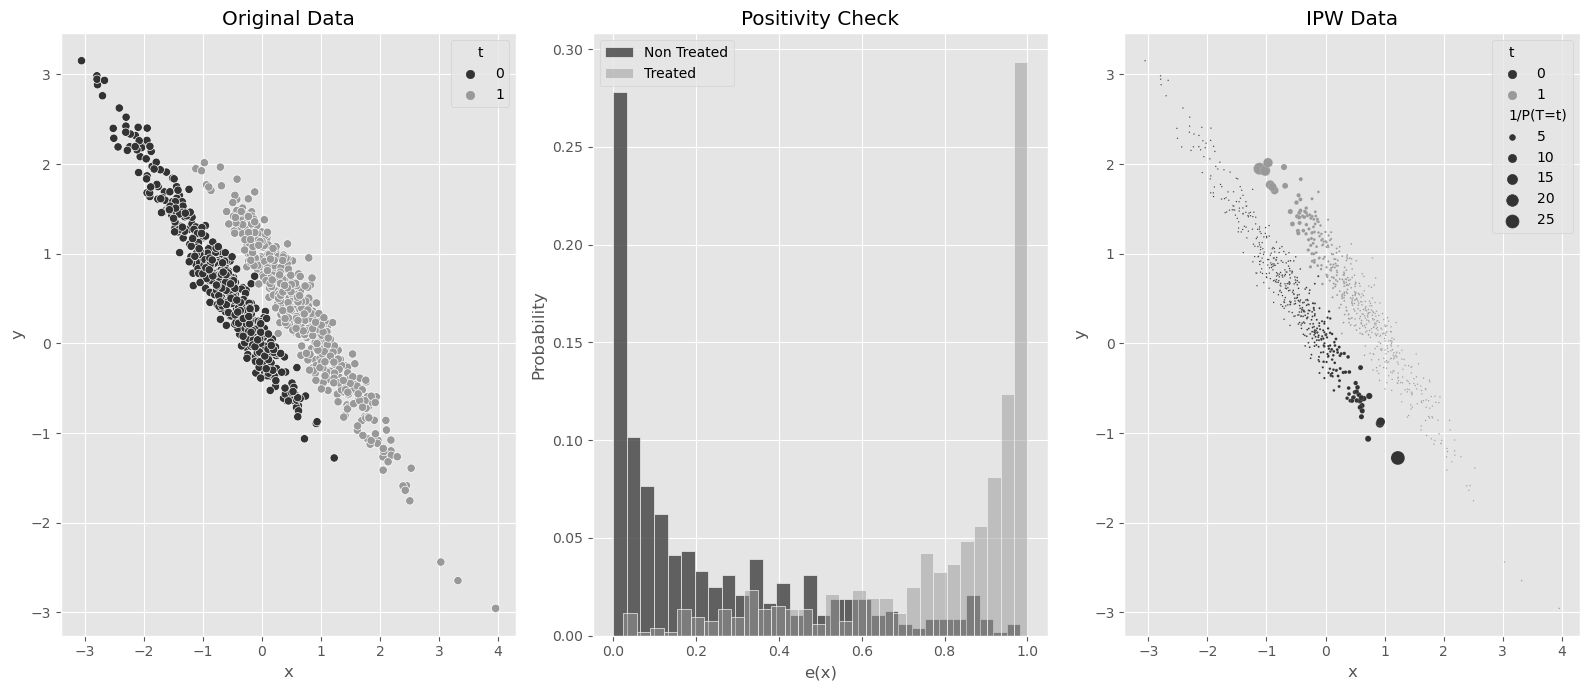

In [24]:
ps_model_sim = smf.logit("""t ~ x""", data=df_no_pos).fit(disp=0)
df_no_pos_ps = df_no_pos.assign(ps=ps_model_sim.predict(df_no_pos))

ps = ps_model_sim.predict(df_no_pos)
w = df_no_pos["t"]*df_no_pos["t"].mean()/ps  + (1-df_no_pos["t"])*((1-df_no_pos["t"].mean())/(1-ps))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16,7))

sns.scatterplot(data=df_no_pos_ps.assign(w=w), x="x", y="y", hue="t", ax=ax1);
ax1.set_title("Original Data")

sns.histplot(df_no_pos_ps.query("t==0")["ps"], stat="probability",
             label="Non Treated", color="C0", bins=30, ax=ax2)
sns.histplot(df_no_pos_ps.query("t==1")["ps"], stat="probability",
             label="Treated", color="C1", alpha=0.5, bins=30, ax=ax2)
ax2.set_xlabel("e(x)")
ax2.legend()
ax2.set_title("Positivity Check")

sns.scatterplot(data=df_no_pos_ps.assign(**{"1/P(T=t)":w}), x="x", y="y", hue="t", ax=ax3, size="1/P(T=t)", sizes=(1, 100));
ax3.set_title("IPW Data")

plt.tight_layout()


In [25]:
est_fn = partial(est_ate_with_ps, ps_formula="x", T="t", Y="y")
print("ATE:",  est_fn(df_no_pos))
print(f"95% C.I.: ", bootstrap(df_no_pos, est_fn))

ATE: 0.5726690860544604
95% C.I.:  [0.36816697 0.76792562]


In [26]:
smf.ols("t ~ x + t", data=df_no_pos).fit().params["t"]

1.0000000000000004

## 5.4 디자인 vs. 모델 기반 식별
* 회귀분석과 역확률 가중치 중 언제 어떤 방법을 사용해야 하는가? 이 선택은 모델 기반 식별과 디자인 기반 식별에 관한 논의와 관련이 있다.
    * 모델 기반 식별 : 처치 및 추가 공변량을 조건부로 설정해 잠재적 결과에 대한 모델 형태로 가정하는 것을 포함
    * 디자인 기반 식별 : 처치 배정 메커니즘에 대한 가정 전제. 
* 회귀 분석은 직교화 관점에서 보면 디자인 기반이면서 잠재적 결과 모델의 추정량 관점에서는 모델 기반이다.
* 따라서 디자인 기반 식별과 모델 기반 식별 중 하나를 선택해야 한다면
    * 처치가 어떻게 배정되었는지 잘 이해하고 있어야 하며
    * 잠재적 결과 모델을 올바르게 지정하는 더 좋은 방법이 있는지 탐색해야 한다.
## 5.5 이중 강건 추정
* 위 두 가지 사항에 대해 확신이 없다면 Doubly Robust Estimate (이중 강건 추정)를 활용할 수 있다.
* 반사실 $Y_t$ 의 이중 강건 추정량은 아래와 같이 표현할 수 있다.
    * $\hat{\mu}_t^{DR} = \frac{1}{N}{\sum{\hat{m}(X)}} + \frac{1}{N}{\sum[\frac{T}{\hat{e}(x)}(Y-\hat{m}(X))]}$
    * $\hat{m}(X)$ 는 $E[Y_t|X]$ 에 대한 모델이며 (ex.선형회귀), $\hat{e}(X)$ 는 $P(T|X)$의 성향점수이다. 강건하다(Robust)라고 하는 이유는 두 요소 중 하나만 올바르게 지정되면 되기 때문이다.
        * 만약 모델 부분이 정확하면 뒤에 term 이 0에 수렴하게 되어 첫 번째 항만 남게 된다.
        * 만약 모델은 부정확하지만 성향점수 모델이 정확하다면 첫 번째 항을 IPW 로 변환할 수 있게 되어 해당 추정량만 남게 된다. 
* 위 추정량은 평균 반사실적 결과인 $Y_t$ 를 추정한다. 따라서 평균처치효과를 추정하려면 $E[Y_0]$ 와 $E[Y_1]$ 각각에 두 추정량을 함께 사용해 두 차이를 계산하면 된다.
    * $ATE = \hat{\mu}_1^{DR}(\hat(m),\hat(e)) - \hat{\mu}_0^{DR}(\hat(m),\hat(e))$
* 코드로 구현하는 경우 성향점수를 로지스틱 회귀로 추정하고 , 실험군 대조군에 해당하는 부분 데이터에 대해 선형회귀를 적합시킨 결과를 수식에 맞게 정의하면 된다.

In [26]:
from sklearn.linear_model import LinearRegression

def doubly_robust(df, formula, T, Y):
    X = dmatrix(formula, df)
    
    ps_model = LogisticRegression(penalty="none",
                                  max_iter=1000).fit(X, df[T])
    ps = ps_model.predict_proba(X)[:, 1]
    
    m0 = LinearRegression().fit(X[df[T]==0, :], df.query(f"{T}==0")[Y])
    m1 = LinearRegression().fit(X[df[T]==1, :], df.query(f"{T}==1")[Y])
    
    m0_hat = m0.predict(X)
    m1_hat = m1.predict(X)

    return (
        np.mean(df[T]*(df[Y] - m1_hat)/ps + m1_hat) -
        np.mean((1-df[T])*(df[Y] - m0_hat)/(1-ps) + m0_hat)
    )

* 데이터를 부트스트랩 함수에 전달해 이중 강건 추정량에 대한 신뢰구간 역시 구할 수 있다.

In [27]:
formula = """tenure + last_engagement_score + department_score
+ C(n_of_reports) + C(gender) + C(role)"""
T = "intervention"
Y = "engagement_score"

print("DR ATE:", doubly_robust(df, formula, T, Y))

est_fn = partial(doubly_robust, formula=formula, T=T, Y=Y)
print("95% CI", bootstrap(df, est_fn))

DR ATE: 0.27115831057931455
95% CI [0.23012681 0.30524944]


### 5.5.1 처치 모델링이 쉬운 경우
* 처치 배정을 모델링하기는 쉽지만 결과 모델이 조금 더 복잡한 경우를 예씨로 성향점수에 따라 주어진 확률로 처치가 베르누이 분포를 따른가고 가정해보자.
* 아래의 예시는 $E[Y_t|X]$가 잘못되어도 $P(T|X)$를 모델링하기가 쉬울 때, 이중 강건 추정이 어떻게 잘 수행되는지를 보여준다.

In [28]:
np.random.seed(123)

n = 10000
x = np.random.beta(1,1, n).round(2)*2
e = 1/(1+np.exp(-(1+1.5*x)))
t = np.random.binomial(1, e)

y1 = 1
y0 = 1 - 1*x**3
y = t*(y1) + (1-t)*y0 + np.random.normal(0, 1, n)

df_easy_t = pd.DataFrame(dict(y=y, x=x, t=t))

print("True ATE:", np.mean(y1-y0))

True ATE: 2.0056243152


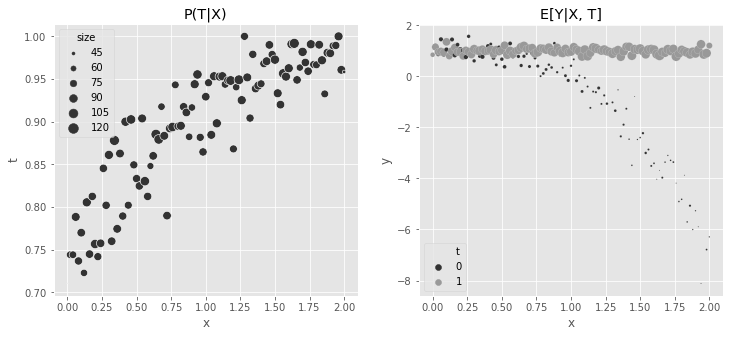

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(data=(df_easy_t
                      .assign(size=1)
                      .groupby(["x"])
                      .agg({"size":"sum", "t":"mean"})
                      .reset_index()),
                x="x", y="t", sizes=(1, 100), size="size", ax=ax1);
ax1.set_title("P(T|X)")

sns.scatterplot(data=(df_easy_t
                      .assign(size=1)
                      .groupby(["x", "t"])
                      .agg({"size":"sum", "y":"mean"})
                      .reset_index()),
                x="x", y="y", hue="t", sizes=(1, 100), size="size", ax=ax2)

ax2.set_title("E[Y|X, T]")

h,l = ax2.get_legend_handles_labels()
plt.legend(h[0:3],l[0:3])


In [30]:
m0 = smf.ols("y~x", data=df_easy_t.query("t==0")).fit()
m1 = smf.ols("y~x", data=df_easy_t.query("t==1")).fit()
regr_ate = (m1.predict(df_easy_t) - m0.predict(df_easy_t)).mean()

print("Regression ATE:", regr_ate)

Regression ATE: 1.786678396833022


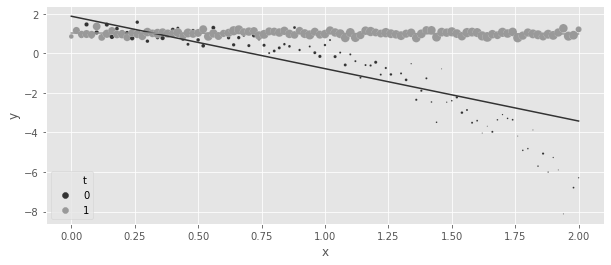

In [31]:
regr = smf.ols("y~x*t", data=df_easy_t).fit()

plt.figure(figsize=(10,4))

sns.scatterplot(data=(df_easy_t
                      .assign(count=1)
                      .groupby(["x", "t"])
                      .agg({"count":"sum", "y":"mean"})
                      .reset_index()),
                x="x", y="y", hue="t", sizes=(1, 100), size="count");

g = sns.lineplot(data=(df_easy_t
                   .assign(pred=regr.fittedvalues)
                   .groupby(["x", "t"])
                   .mean()
                   .reset_index()),
             x="x", y="pred", hue="t", sizes=(1, 100))

h,l = g.get_legend_handles_labels()
plt.legend(h[0:3],l[0:3])



In [32]:
m = smf.ols("y~t*(x + np.power(x, 3))", data=df_easy_t).fit()
regr_ate = (m.predict(df_easy_t.assign(t=1))
            - m.predict(df_easy_t.assign(t=0))).mean()

print("Regression ATE:", regr_ate)

Regression ATE: 1.9970999747190072


In [33]:
est_fn = partial(est_ate_with_ps, ps_formula="x", T="t", Y="y")
print("Propensity Score ATE:", est_fn(df_easy_t))
print("95% CI", bootstrap(df_easy_t, est_fn))

Propensity Score ATE: 2.002350388474011
95% CI [1.80802227 2.22565667]


In [34]:
est_fn = partial(doubly_robust, formula="x", T="t", Y="y")
print("DR ATE:", est_fn(df_easy_t))
print("95% CI", bootstrap(df_easy_t, est_fn))

DR ATE: 2.001617934263116
95% CI [1.87088771 2.145382  ]


### 5.5.2 결과 모델링이 쉬운 경우
* 아래의 예시는 반대로 $E[Y_t|X]$ 보다 $P(T|X)$ 가 더 모델링하기 복잡한 경우이다. 결과함수는 단순 선형 이지만 $P(T|X)$가 비선형인 경우이다.

In [35]:
np.random.seed(123)

n = 10000
x = np.random.beta(1,1, n).round(2)*2
e = 1/(1+np.exp(-(2*x - x**3)))
t = np.random.binomial(1, e)

y1 = x
y0 = y1 + 1 # ate of -1
y = t*(y1) + (1-t)*y0 + np.random.normal(0, 1, n)

df_easy_y = pd.DataFrame(dict(y=y, x=x, t=t))

print("True ATE:", np.mean(y1-y0))

True ATE: -1.0


The same kind of plot from before can be used to show the complex functional form for $P(T|X)$ and the simplicity of $E[Y_t|X]$.

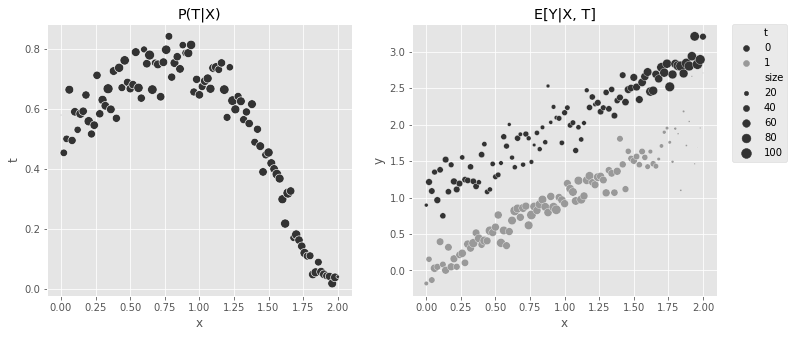

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(data=(df_easy_y
                      .assign(size=1)
                      .groupby(["x"])
                      .agg({"size":"sum", "t":"mean"})
                      .reset_index()),
                x="x", y="t", sizes=(1, 100), size="size", ax=ax1, legend=None);

sns.scatterplot(data=(df_easy_y
                      .assign(size=1)
                      .groupby(["x", "t"])
                      .agg({"size":"sum", "y":"mean"})
                      .reset_index()),
                x="x", y="y", hue="t", sizes=(1, 100), size="size", ax=ax2);

ax1.set_title("P(T|X)")
ax2.set_title("E[Y|X, T]")

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)


In [37]:
est_fn = partial(est_ate_with_ps, ps_formula="x", T="t", Y="y")
print("Propensity Score ATE:", est_fn(df_easy_y))
print("95% CI", bootstrap(df_easy_y, est_fn))

Propensity Score ATE: -1.1042900278680896
95% CI [-1.14326893 -1.06576358]


In [38]:
m0 = smf.ols("y~x", data=df_easy_y.query("t==0")).fit()
m1 = smf.ols("y~x", data=df_easy_y.query("t==1")).fit()
regr_ate = (m1.predict(df_easy_y) - m0.predict(df_easy_y)).mean()

print("Regression ATE:", regr_ate)

Regression ATE: -1.0008783612504342


In [39]:
est_fn = partial(doubly_robust, formula="x", T="t", Y="y")
print("DR ATE:", est_fn(df_easy_y))
print("95% CI", bootstrap(df_easy_y, est_fn))

DR ATE: -1.0028459347805823
95% CI [-1.04156952 -0.96353366]


## 5.6 연속형 처치에서의 일반화 성향점수
* 연속형 처치인 경우는 이산형보다 훨씬 다루기가 복잡해 인과추론에서도 이 문제에 대한 확실한 해결책은 없다.
* 가장 간단한 방법은 연속형 처치를 이산화하는 방법이다. 이 방법외 일반화 성향점수(generalized propensity score) 를 사용하는 방법도 있다.
* 예시
    * 대출 금리가 고객이 대출금을 상환하는 기간에 어떤 영향을 미치는지
        * 직관적으로 금리가 대출 상환기간에 미치는 영향은 음수임
        * 금리는 두 가지 ml 모델을 통해 배정되었고 금리 결정 과정에 임의의 가우스 잡음을 추가해 정책이 비결정적이며 양수성 가정을 위배하지 않도록 처치
        * 관측 이자 데이터에는 교란 요인인 ml_1, ml_2, 상환기간 정보가 포함됨

In [28]:
df_cont_t = pd.read_csv("./data/interest_rate.csv")

df_cont_t.head()

,ml_1,ml_2,interest,duration
0,0.392938,0.326285,7.1,12.0
1,-0.427721,0.679573,5.6,17.0
2,-0.546297,0.647309,11.1,12.0
3,0.102630,-0.264776,7.2,18.0
4,0.438938,-0.648818,9.5,19.0


In [29]:
m_naive = smf.ols("duration ~ interest", data=df_cont_t).fit()
m_naive.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,14.5033,0.226,64.283,0.000,14.061,14.946
interest,0.3393,0.029,11.697,0.000,0.282,0.396


* 가장 먼저 해결해야할 문제는 연속형 변수는 어디서나 확률이 0이라는 사실이다. $P(T=t)=0$ 이는 확률이 밀도 아래의 면적으로 표현되고 한 점의 면점은 항상 0이기 떄문이다.
* 가능한 해결책 중 하나는 조건부 확률 대신 조건부 밀도함수를 사용하는 것이다. 이 접근법은 처치 분포를 정해야하는 또 다른 문제가 있다. 
* 아래 예시에서는 단순화를 위해 처치는 정규분포에서 추출되었다고 가정한다. 또한 이분산이 아닌 등분산을 가정한다.

In [30]:
model_t = smf.ols("interest~ml_1+ml_2", data=df_cont_t).fit()

* 적합된 값을 $\mu_i$로 사용하고 잔차의 표준편차를 $\sigma$로 사용한다. 이렇게 하면 조건부 밀도의 추정값을 얻을 수 있다.
* 그다음 주어진 처치에 해당하는 조건부 밀도를 평가하기 위해 밀도함수의 x인수에 T를 전달한다.

In [31]:
def conditional_density(x, mean, std):
    denom = std*np.sqrt(2*np.pi)
    num = np.exp(-((1/2)*((x-mean)/std)**2))
    return (num/denom).ravel()
    

gps = conditional_density(df_cont_t["interest"],
                          model_t.fittedvalues,
                          np.std(model_t.resid))
gps

array([0.1989118 , 0.14524168, 0.03338421, ..., 0.07339096, 0.19365006,
       0.15732008])

In [32]:
from scipy.stats import norm

gps = norm(loc=model_t.fittedvalues,
           scale=np.std(model_t.resid)).pdf(df_cont_t["interest"])
gps

array([0.1989118 , 0.14524168, 0.03338421, ..., 0.07339096, 0.19365006,
       0.15732008])

:::{admonition} Beyond the Normal
If the treatment follows another distribution other than the normal, you can use generalized linear models (`glm`) to fit it. For example, if $T$ was assigned according to a Poisson distribution, you could build the GPS weights with something like the following code
 
```python
import statsmodels.api as sm
from scipy.stats import poisson
 
mt = smf.glm("t~x1+x2",
             data=df, family=sm.families.Poisson()).fit()
 
gps = poisson(mu=m_pois.fittedvalues).pmf(df["t"])
 
w = 1/gps
```
 
:::
 
 
Using the inverse of the GPS as weights in a regression model can adjust for the bias. You can see that now you'll find a negative effect of interest on duration, which makes more business sense. 

In [45]:
final_model = smf.wls("duration~interest",
                      data=df_cont_t, weights=1/gps).fit()

final_model.params["interest"]

-0.6673977919925854

* 아래의 그래프에서는 ml_1 만 사용해 금리를 적합시킨 경우를 가정했을 때의 가중치를 볼 수 있다.
    * 첫 번째 그래프는 원본 데이터를 교란 요인 ml_1에 따라 색상으로 구분한 결과이다. 점수가 낮은 고객은 일반적으로 대출 상환기간을 길게 선택하고 점수가 낮은 고객에게는 더 높은 금리가 배정된다. 결과적으로 금리와 상환 기간 간의 상향편향이 존재한다.
    * 두 번째 그래프는 처치 모델의 적합된 값을 보여주는데 일반화 성향점수로 구성된 가중치도 같이 표시되어 있다. 가중치는 선에서 멀어질수록 커지는 모습을 볼 수 있다.
    * 마지막 그래프는 가중치를 동일하게 유지하면서 금리와 상환기간 간의 관계를 보여준다. ml_1 의 극단 값에서 높은 이자율이 드물게 나타나므로 일반화 성향점수 가중치의 역수는 이러한 포인트에 높은 중요도를 부여한다.

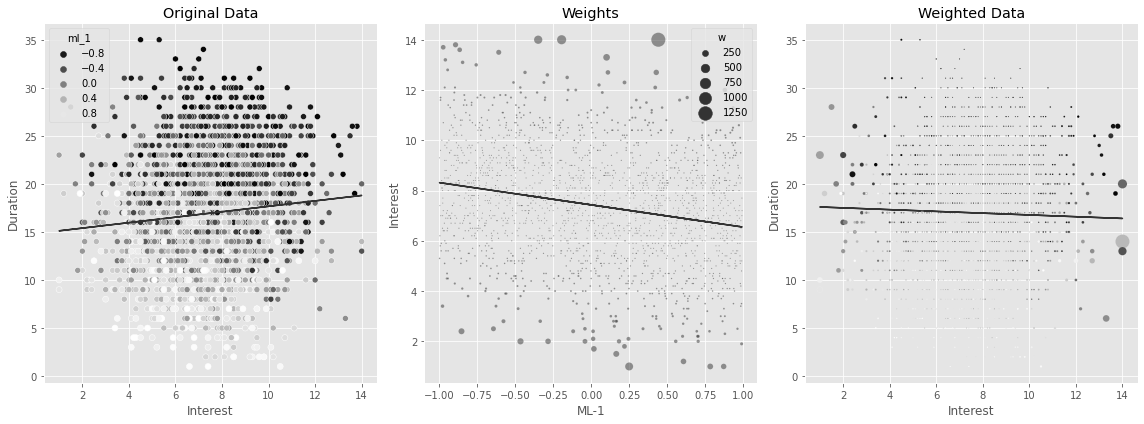

In [46]:
np.random.seed(1)
sample = df_cont_t.sample(2000)



model_ex = smf.ols("interest~ml_1", data=sample).fit()
gps_ex = norm(loc=model_ex.fittedvalues, scale=np.std(model_ex.resid)).pdf(sample["interest"])

w_ex = 1/gps_ex

m = smf.ols("duration~interest", data=sample).fit()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

sns.scatterplot(data=sample, x="interest", y="duration", alpha=1, ax=ax1, hue="ml_1", palette = 'gray')
ax1.plot(sample["interest"], m.fittedvalues)

ax1.set_ylabel("Duration")
ax1.set_xlabel("Interest")
ax1.set_title("Original Data");


sns.scatterplot(data=sample.assign(w=w_ex), x="ml_1", y="interest",size="w",
                sizes=(1,200), alpha=0.5, ax=ax2)
ax2.plot(sample["ml_1"], model_ex.fittedvalues)
ax2.set_ylabel("Interest")
ax2.set_xlabel("ML-1")
ax2.set_title("Weights")


m = smf.wls("duration~interest", data=sample, weights=w_ex).fit()

sns.scatterplot(data=sample.assign(w=w_ex), x="interest", y="duration",size="w",
                sizes=(1,200), alpha=1, ax=ax3, hue="ml_1", legend=None, palette = 'gray')
ax3.plot(sample["interest"], m.fittedvalues)
ax3.set_ylabel("Duration")
ax3.set_xlabel("Interest")
ax3.set_title("Weighted Data")

plt.tight_layout()



In [47]:
stabilizer = norm(
    loc=df_cont_t["interest"].mean(),
    scale=np.std(df_cont_t["interest"] - df_cont_t["interest"].mean())
).pdf(df_cont_t["interest"])

gipw =  stabilizer/gps

print("Original Sample Size:", len(df_cont_t))
print("Effective Stable Weights Sample Size:", sum(gipw))

Original Sample Size: 10000
Effective Stable Weights Sample Size: 9988.19595174861


Text(0.5, 1.0, 'Weighted Data')

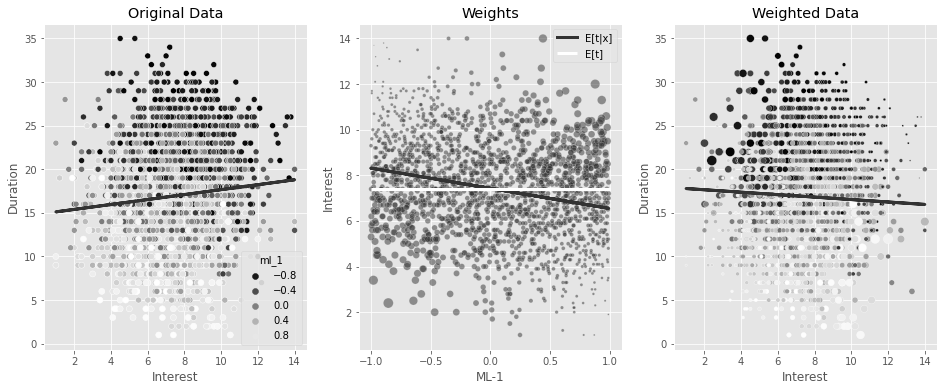

In [48]:
np.random.seed(1)
sample = df_cont_t.sample(2000)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

model_ex = smf.ols("interest~ml_1", data=sample).fit()
gps_ex = norm(loc=model_ex.fittedvalues, scale=np.std(model_ex.resid)).pdf(sample["interest"])
stabilizer_ex = norm(
    loc=sample["interest"].mean(),
    scale=np.std(sample["interest"] - sample["interest"].mean())
).pdf(sample["interest"])


w_ex = stabilizer_ex/gps_ex

m = smf.ols("duration~interest", data=sample).fit()

sns.scatterplot(data=sample, x="interest", y="duration", alpha=1, ax=ax1, hue="ml_1", palette = 'gray')
ax1.plot(sample["interest"], m.fittedvalues, lw=3)
ax1.set_ylabel("Duration")
ax1.set_xlabel("Interest")
ax1.set_title("Original Data");


sns.scatterplot(data=sample.assign(w=w_ex), x="ml_1", y="interest",size="w",
                sizes=(1,100), alpha=0.5, ax=ax2)

ax2.plot(sample["ml_1"], model_ex.fittedvalues, label="E[t|x]", lw=3)

ax2.hlines(sample["interest"].mean(), -1, 1, label="E[t]", color="C2", lw=3)
ax2.set_ylabel("Interest")
ax2.set_xlabel("ML-1")
ax2.set_title("Weights")

h,l = ax2.get_legend_handles_labels()
ax2.legend(h[5:],l[5:],)

m = smf.wls("duration~interest", data=sample, weights=w_ex).fit()

sns.scatterplot(data=sample.assign(w=w_ex), x="interest", y="duration",size="w",
                sizes=(1,100), alpha=1, ax=ax3, hue="ml_1", legend=None, palette = 'gray')
ax3.plot(sample["interest"], m.fittedvalues, lw=3)
ax3.set_ylabel("Duration")
ax3.set_xlabel("Interest")
ax3.set_title("Weighted Data")



In [49]:
final_model = smf.wls("duration ~ interest",
                      data=df_cont_t, weights=gipw).fit()

final_model.params["interest"]

-0.7787046278134069

* T 가 연속형 처치인 경우에는 가중치 안정화는 결과에 큰 영향을 준다. 추정하려는 실제 매개변수값에 더 가까워지게 하고 분산도 크게 줄여주는 역할을 한다.

In [50]:
def gps_normal_ate(df, formula, T, Y, stable=True):
    mt = smf.ols(f"{T}~"+formula, data=df).fit()
    gps = norm(loc=mt.fittedvalues, scale=np.std(mt.resid)).pdf(df[T])
    stabilizer = norm(
        loc=df[T].mean(),
        scale=np.std(df[T] - df[T].mean())
    ).pdf(df[T])
    
    if stable:
        return smf.wls(f"{Y}~{T}", data=df, weights=stabilizer/gps).fit().params[T]
    else:
        return smf.wls(f"{Y}~{T}", data=df, weights=1/gps).fit().params[T]

print("95% CI, non-stable: ", bootstrap(df_cont_t, partial(gps_normal_ate, formula="ml_1 + ml_2", T="interest", Y="duration", stable=False)))
print("95% CI, stable: ", bootstrap(df_cont_t, partial(gps_normal_ate, formula="ml_1 + ml_2", T="interest", Y="duration")))

95% CI, non-stable:  [-0.81074164 -0.52605933]
95% CI, stable:  [-0.85834311 -0.71001914]


## 5.7 요약
* 역확률 가중치(IPW)는 편향을 보정하는 핵심 방법 중 하나이다.
* 회귀분석+직교화, IPW 모두 처치를 모델링해야 한다. 
* 직교화는 처치를 잔차화하여, 처치 모델링에 사용된 공변량 X와 선형 독립(직교)인 새로운 공간으로 투영한다.
* IPW는 처치의 차원을 그대로 유지하지만, 데이터를 처치 성향점수의 역수로 재조정한다.


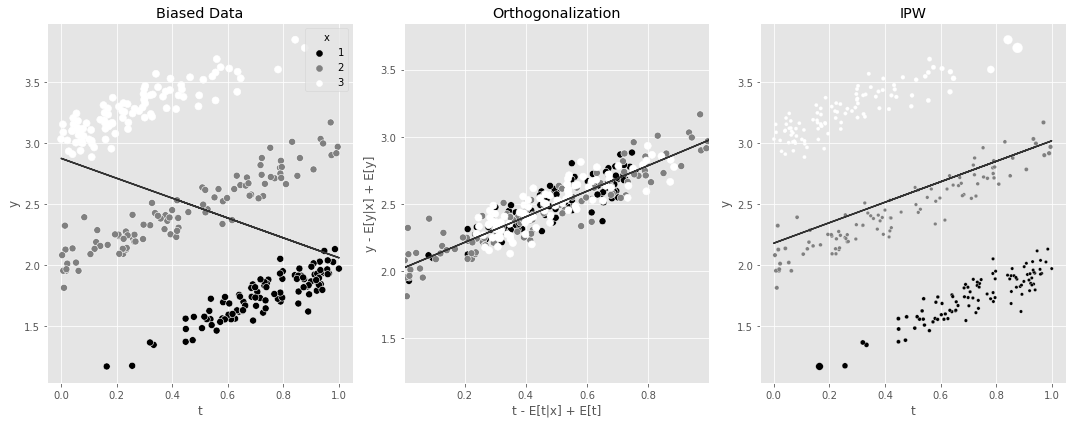

In [51]:
np.random.seed(1)

n=100

df1 = pd.DataFrame(dict(
    x=1,
    t=np.random.beta(2.5,1, n),
)).assign(y = lambda d: np.random.normal(d["x"]+d["t"], 0.1))

df2 = pd.DataFrame(dict(
    x=2,
    t=np.random.beta(1,1, n),
)).assign(y = lambda d: np.random.normal(d["x"]+d["t"], 0.1))

df3 = pd.DataFrame(dict(
    x=3,
    t=np.random.beta(1,2.5, n),
)).assign(y = lambda d: np.random.normal(d["x"]+d["t"], 0.1))


df_example = pd.concat([df1, df2, df3])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,6))

m = smf.ols("y~t", data=df_example).fit()
sns.scatterplot(data=df_example, x="t", y="y",  hue="x", s=50, ax=ax1, palette = 'gray')
ax1.plot(df_example["t"], m.fittedvalues)
ax1.set_title("Biased Data")

## Orthogonalization

mt = smf.ols("t~x", data=df_example).fit()
my = smf.ols("y~x", data=df_example).fit()

df_ex_res = df_example.assign(
    t_res = mt.resid + df_example["t"].mean(),
    y_res = my.resid + df_example["y"].mean()
)

m_final = smf.ols("y_res~t_res", data=df_ex_res).fit()
sns.scatterplot(data=df_ex_res, x="t_res", y="y_res",  hue="x", s=50, ax=ax2, legend=None, palette = 'gray')
ax2.plot(df_ex_res["t_res"], m_final.fittedvalues)

ax2.set_ylim(df_example["y"].min(), df_example["y"].max())
ax2.set_xlim(df_example["t"].min(), df_example["t"].max())

ax2.set_ylabel("y - E[y|x] + E[y]")
ax2.set_xlabel("t - E[t|x] + E[t]")
ax2.set_title("Orthogonalization")


## IPW
gps_example = norm(loc=mt.fittedvalues, scale=np.std(mt.resid)).pdf(df_example["t"])
stabilizer_example = norm(
    loc=df_example["t"].mean(),
    scale=np.std(df_example["t"] - df_example["t"].mean())
).pdf(df_example["t"])


w_example = stabilizer_example/gps_example
mw = smf.wls("y~t", data=df_example, weights=w_example).fit()


sns.scatterplot(data=df_example.assign(w=w_example), x="t", y="y",  hue="x", ax=ax3, size="w",
                legend=None, sizes=(11,100), palette = 'gray')
ax3.plot(df_example["t"], mw.fittedvalues)
ax3.set_title("IPW")

plt.tight_layout()


* 위 그래프는 두 가지 접근법을 비교한 결과이다.
    * 첫 번째 그래프에서 t에 대한 y의 회귀선은 원래 데이터가 포함되며 , x에 따른 편향 때문에 기울기가 음수이다.
    * 직교화와 IPW 의 각 회귀선 결과를 보면 t가 y에 미치는 양의 인과효과를 볼 수 있다.
    * 처치가 이산형이면 IPW 를 사용하고 특히 이중 강건 추정법을 함께 사용하는 것이 좋다. 처치가 연속형인 경우에는 회귀 모델링을 활용하는 것이 좋다고 볼 수 있다.

### 추가 정리

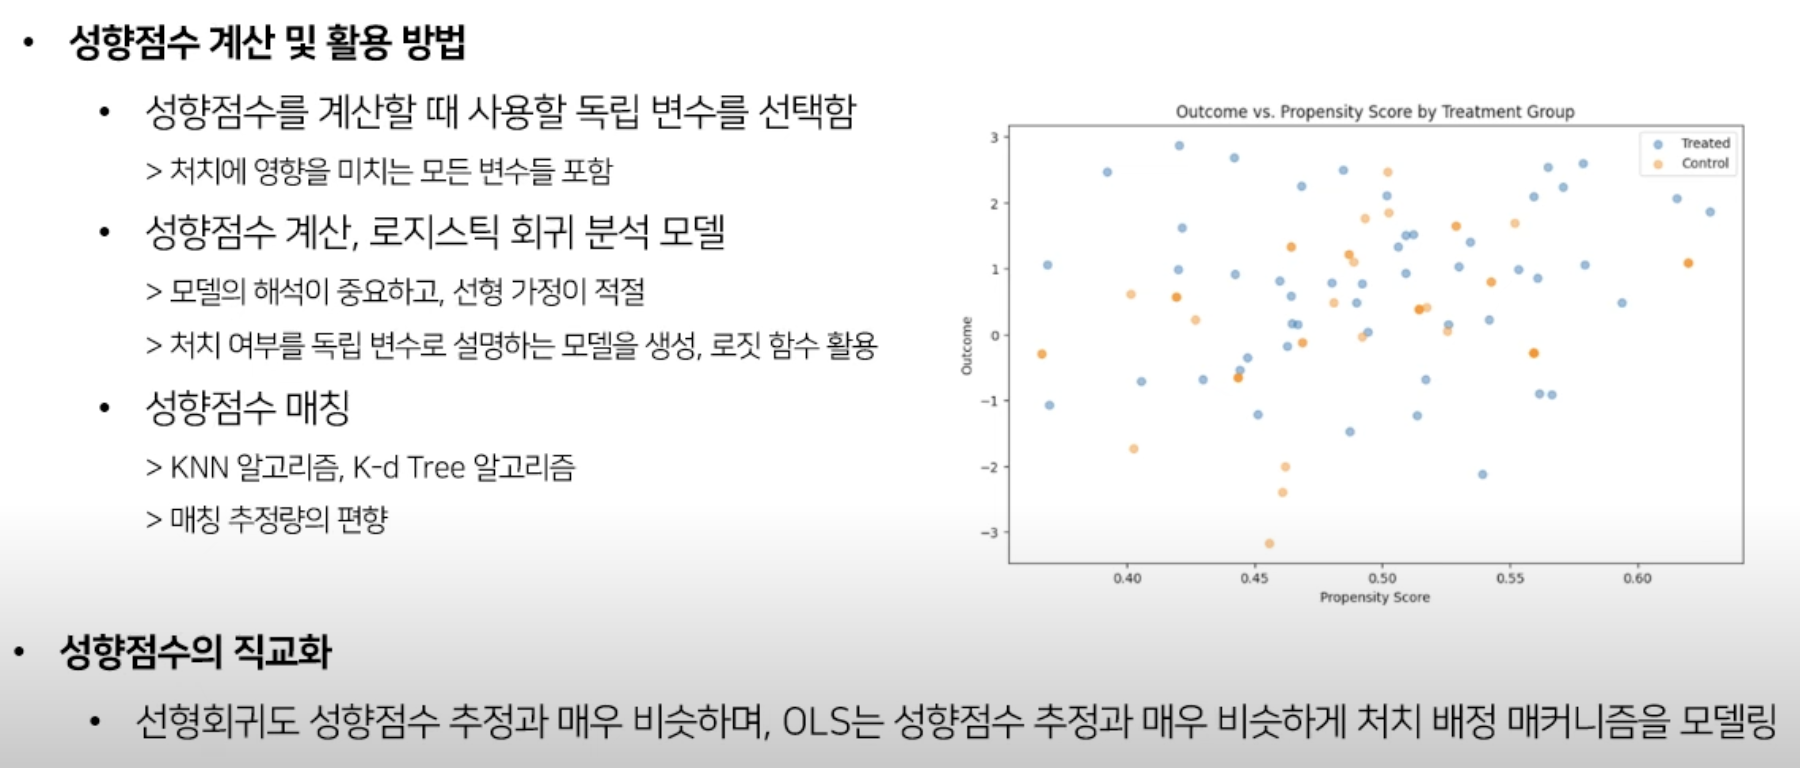

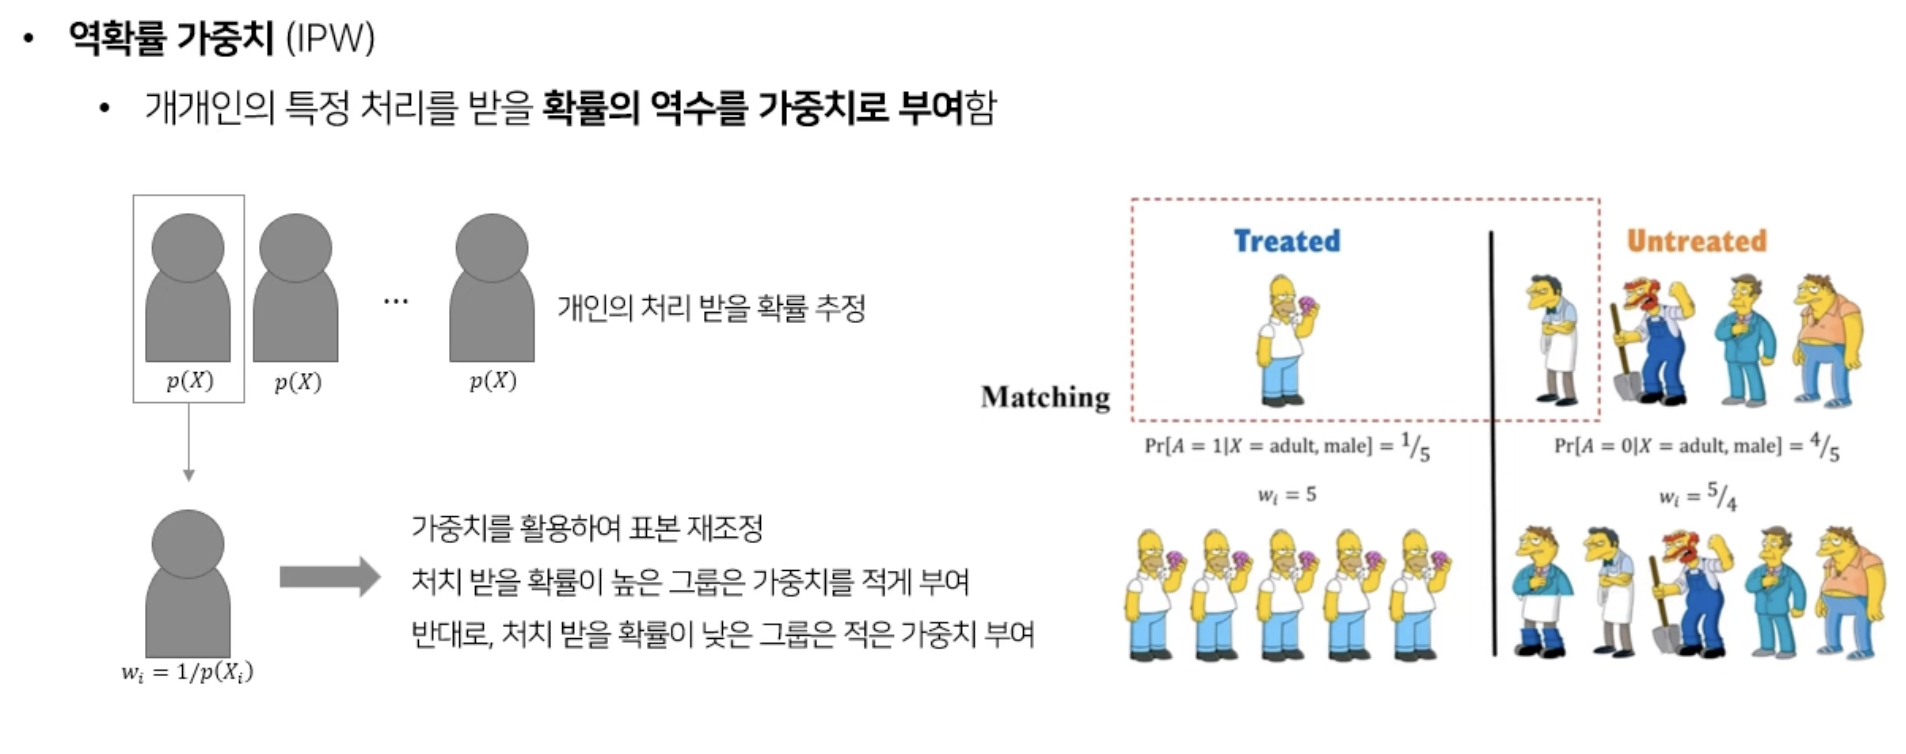

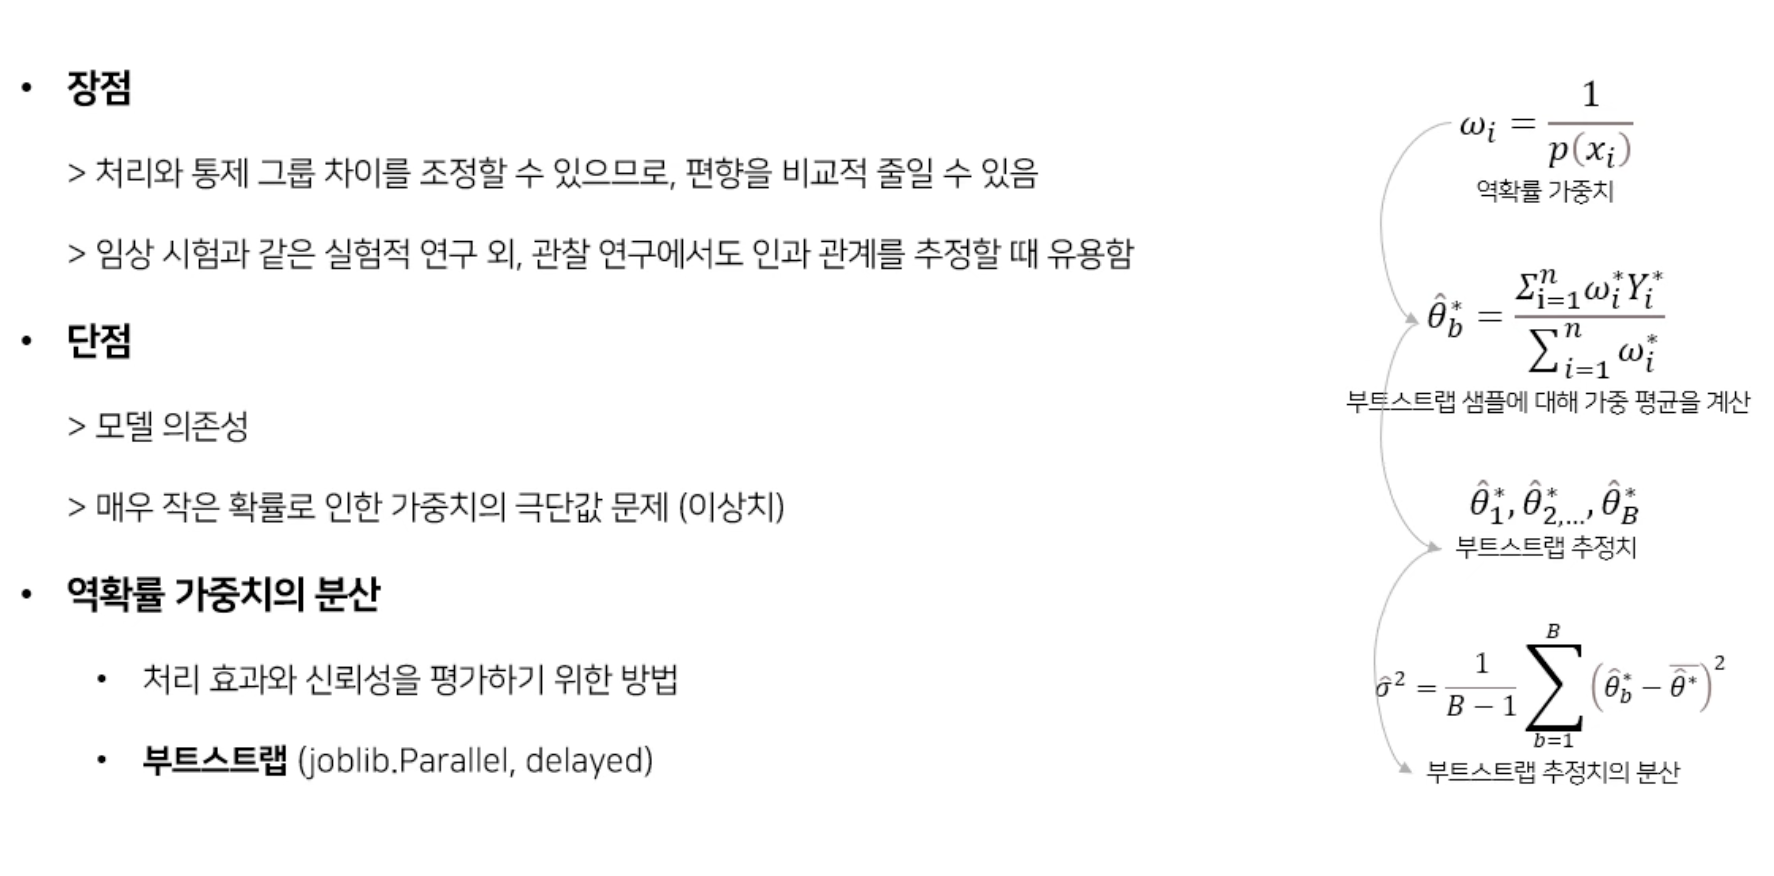

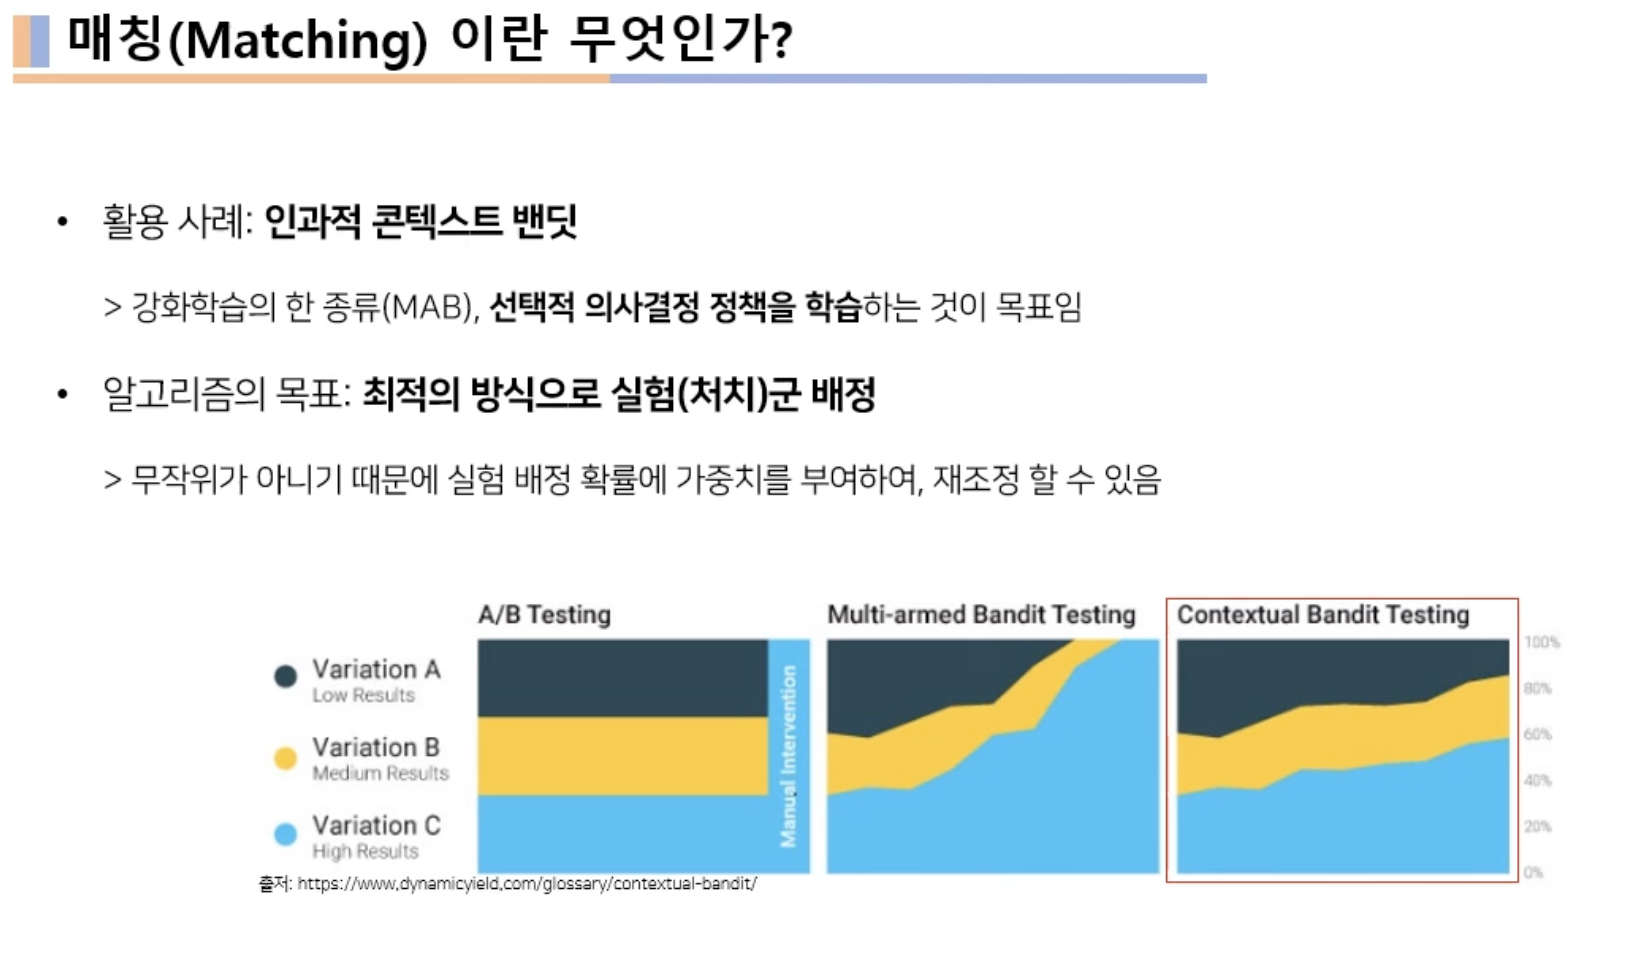

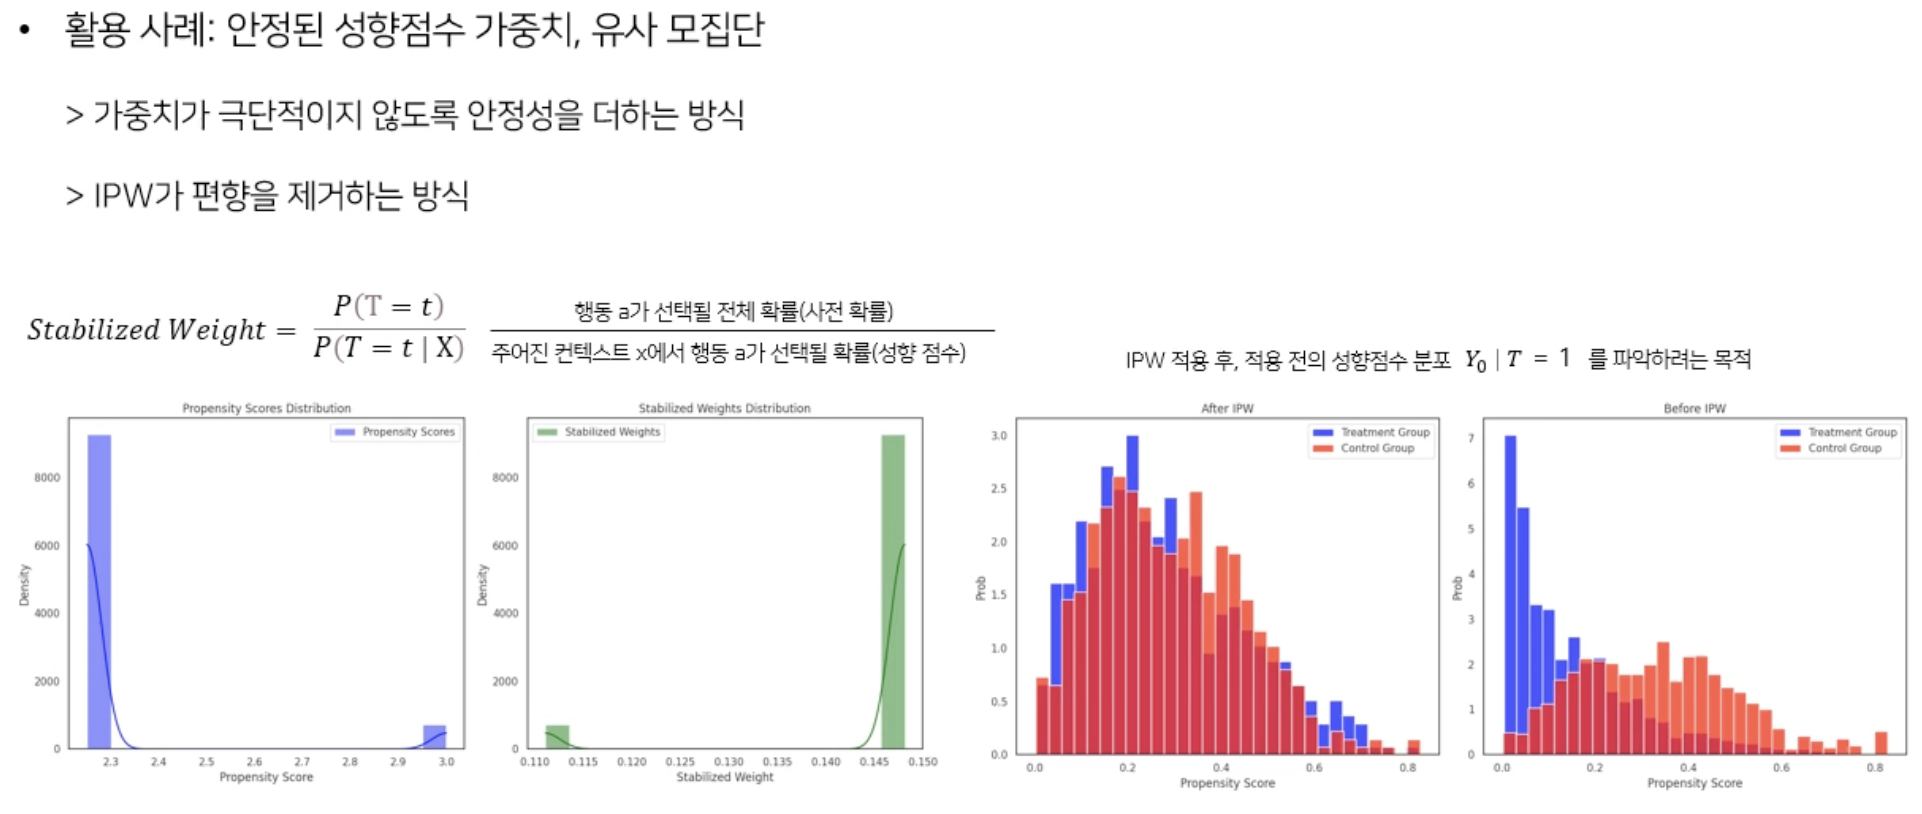

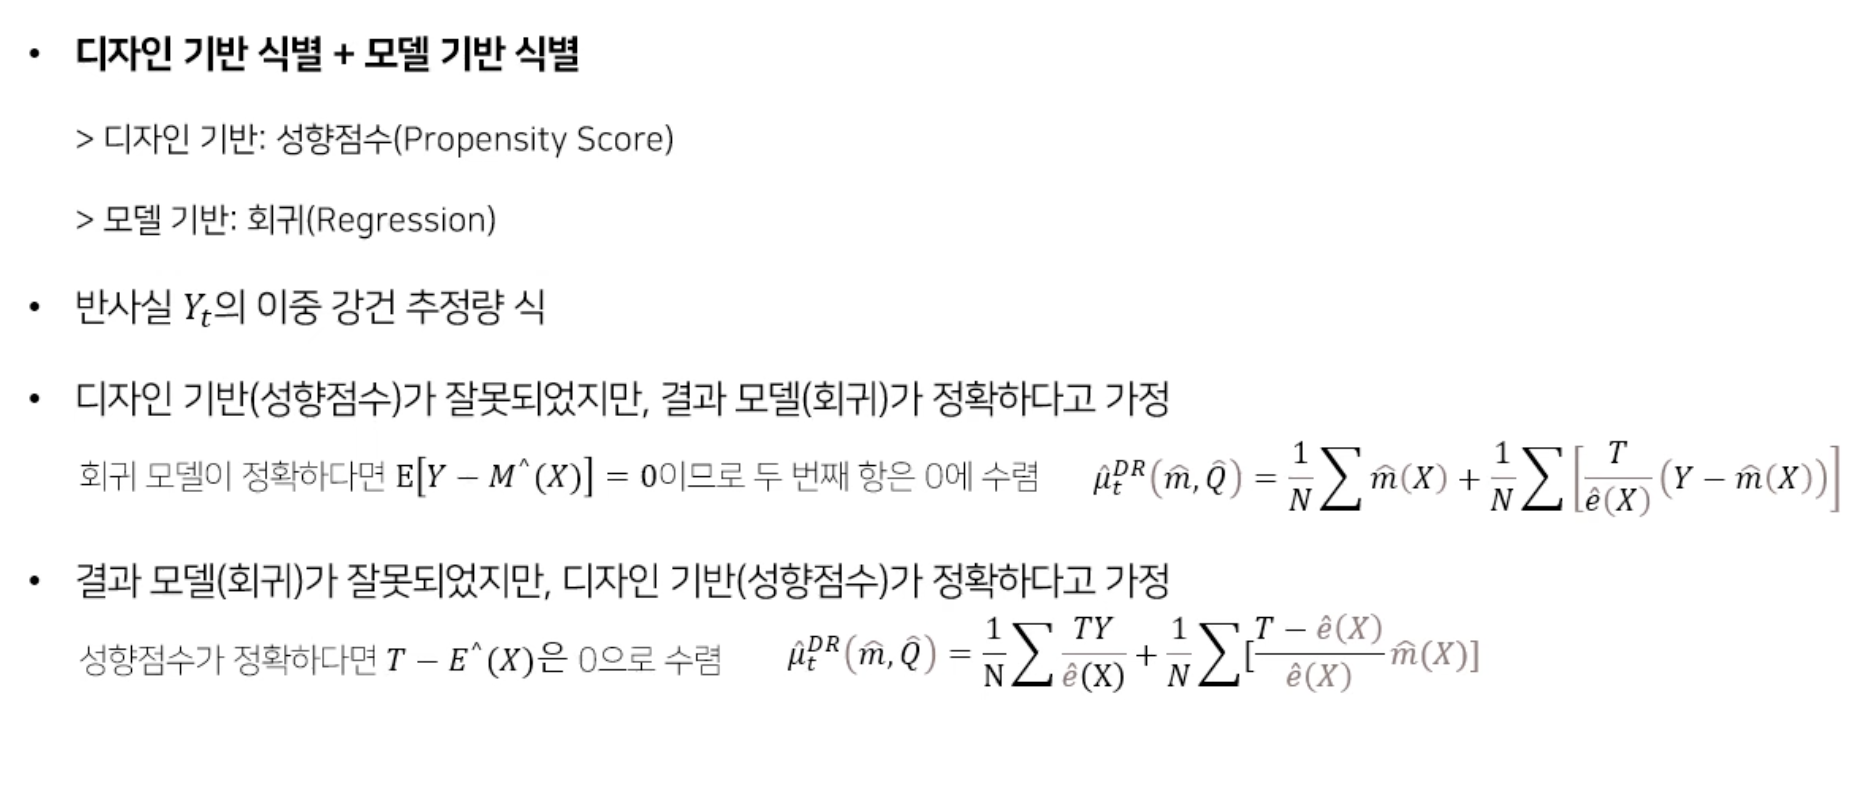

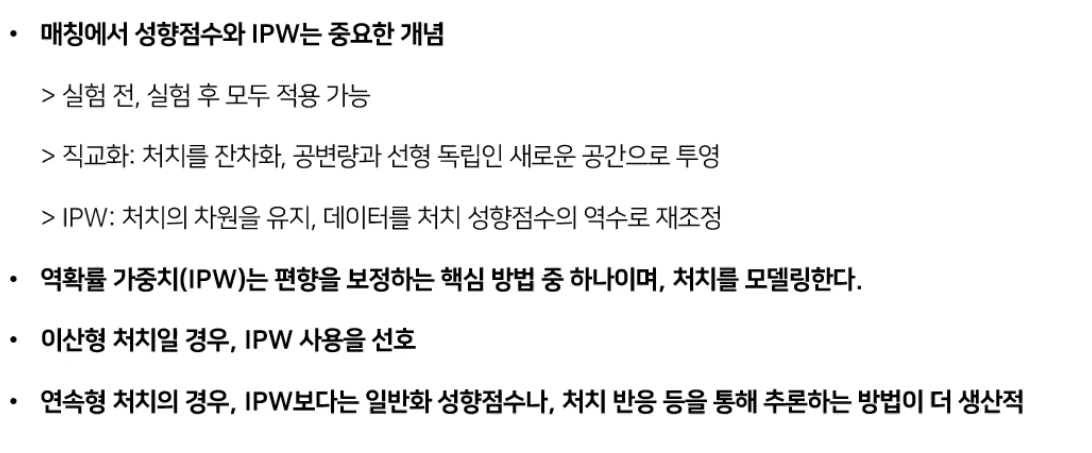